In [10]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import torch as pt
import os
import PcmPy as pcm
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.util as ut
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.evaluation as ev
from OptimalBattery.util import eigenval_crit,build_combinations, combination_vectors
from DCBC.utilities import compute_dist
import nitools as nt
from IndividualParcellation.evaluate import calc_test_dcbc


In [11]:
# pytorch cuda global flag: True - cuda; False - cpu
if pt.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
pt.set_default_device(DEVICE)
pt.set_default_dtype(pt.float32)

print('DEVICE:', DEVICE)

DEVICE: cuda


In [33]:
# load data and info from pickle
with open('E:/data/data_mdtb_s1_SUIT3.pkl', 'rb') as f:
    data_mdtb_s1 = pickle.load(f)


#load info
with open('E:/data/info_mdtb_1.pkl', 'rb') as f:
    info = pickle.load(f)

In [68]:

n_subjects, n_conditions_x_runs, n_voxels = data_mdtb_s1.shape


new_data = np.zeros((n_subjects, n_conditions_x_runs, n_voxels))

new_info_list = []

condition_names = info['cond_name'].unique()

for condition_idx, cond_name in enumerate(condition_names):
    # Get the indices for all 16 repetitions of the current condition
    indices = info[info['cond_name'] == cond_name].index

    # Split into 4 groups, each having 4 repetitions
    for run_reconstruct in range(4):
        # Extract the relevant indices for this group of 4 repetitions
        selected_indices = indices[run_reconstruct * 4 : (run_reconstruct + 1) * 4]

        # Place these rows in the new data matrix in the appropriate position
        # We place them sequentially to form the new data structure
        new_data[:, (condition_idx * 16) + (run_reconstruct * 4): (condition_idx * 16) + (run_reconstruct * 4) + 4, :] = \
            data_mdtb_s1[:, selected_indices, :]

        # Generate new condition names and update the info entries
        for sub_idx in range(4):
            # Create new condition name like ToM1, ToM2, ...
            new_condition_name = f"{cond_name}{sub_idx + 1}"
            
            # Create a new info entry
            new_info_list.append({
                'cond_name': new_condition_name,
                'run': run_reconstruct + 1,  # Assign to the virtual run index
                'task_name': info.loc[indices[0], 'task_name'],  # Keep the original task name
                'cond_num': condition_idx + 1,  # Use the condition index as a unique identifier
                'instruction': info.loc[indices[0], 'instruction'],
                'cond_code': f"{new_condition_name}-run{run_reconstruct + 1}"
            })

# Step 5: Convert the list of new info entries into a DataFrame
info_new = pd.DataFrame(new_info_list)



In [192]:
data_mdtb_s1[1,30,:]

array([ 0.03689736, -0.0677153 ,  0.28328835, ..., -0.1019797 ,
       -0.09139765, -0.07605602])

In [191]:
new_data[1,17,:]

array([ 0.03689736, -0.0677153 ,  0.28328835, ..., -0.1019797 ,
       -0.09139765, -0.07605602])

In [156]:
info_new

,cond_name,run,task_name,cond_num,instruction,cond_code
0,NoGo1,1,GoNoGo,1,0,NoGo1-run1
1,NoGo2,1,GoNoGo,1,0,NoGo2-run1
2,NoGo3,1,GoNoGo,1,0,NoGo3-run1
3,NoGo4,1,GoNoGo,1,0,NoGo4-run1
4,NoGo1,2,GoNoGo,1,0,NoGo1-run2
...,...,...,...,...,...,...
459,rest4,3,rest,29,0,rest4-run3
460,rest1,4,rest,29,0,rest1-run4
461,rest2,4,rest,29,0,rest2-run4
462,rest3,4,rest,29,0,rest3-run4


# get the G matrix

In [105]:
n_conds = len(np.unique(info_new['cond_name']))
n_runs = len(np.unique(info_new['run']))
cond_names = info_new['cond_name'].unique()

In [106]:
cond_names

array(['NoGo1', 'NoGo2', 'NoGo3', 'NoGo4', 'Go1', 'Go2', 'Go3', 'Go4',
       'ToM1', 'ToM2', 'ToM3', 'ToM4', 'VideoAct1', 'VideoAct2',
       'VideoAct3', 'VideoAct4', 'VideoKnots1', 'VideoKnots2',
       'VideoKnots3', 'VideoKnots4', 'UnpleasantScenes1',
       'UnpleasantScenes2', 'UnpleasantScenes3', 'UnpleasantScenes4',
       'PleasantScenes1', 'PleasantScenes2', 'PleasantScenes3',
       'PleasantScenes4', 'Math1', 'Math2', 'Math3', 'Math4',
       'DigitJudgement1', 'DigitJudgement2', 'DigitJudgement3',
       'DigitJudgement4', 'CheckerBoard1', 'CheckerBoard2',
       'CheckerBoard3', 'CheckerBoard4', 'SadFaces1', 'SadFaces2',
       'SadFaces3', 'SadFaces4', 'HappyFaces1', 'HappyFaces2',
       'HappyFaces3', 'HappyFaces4', 'IntervalTiming1', 'IntervalTiming2',
       'IntervalTiming3', 'IntervalTiming4', 'MotorImagery1',
       'MotorImagery2', 'MotorImagery3', 'MotorImagery4', 'FingerSimple1',
       'FingerSimple2', 'FingerSimple3', 'FingerSimple4', 'FingerSeq1',
       'F

In [194]:
cond_vec = np.concatenate([np.tile(np.arange(start, start + 4), 4) for start in range(1, 117, 4)])
part_vec = np.tile(np.repeat([1, 2, 3, 4], 4), 29)


Gs_list = []
for i in range(new_data.shape[0]):
    Gs,E = pcm.util.est_G_crossval(new_data[i], cond_vec, part_vec)
    Gs_list.append(Gs)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)


<Axes: >

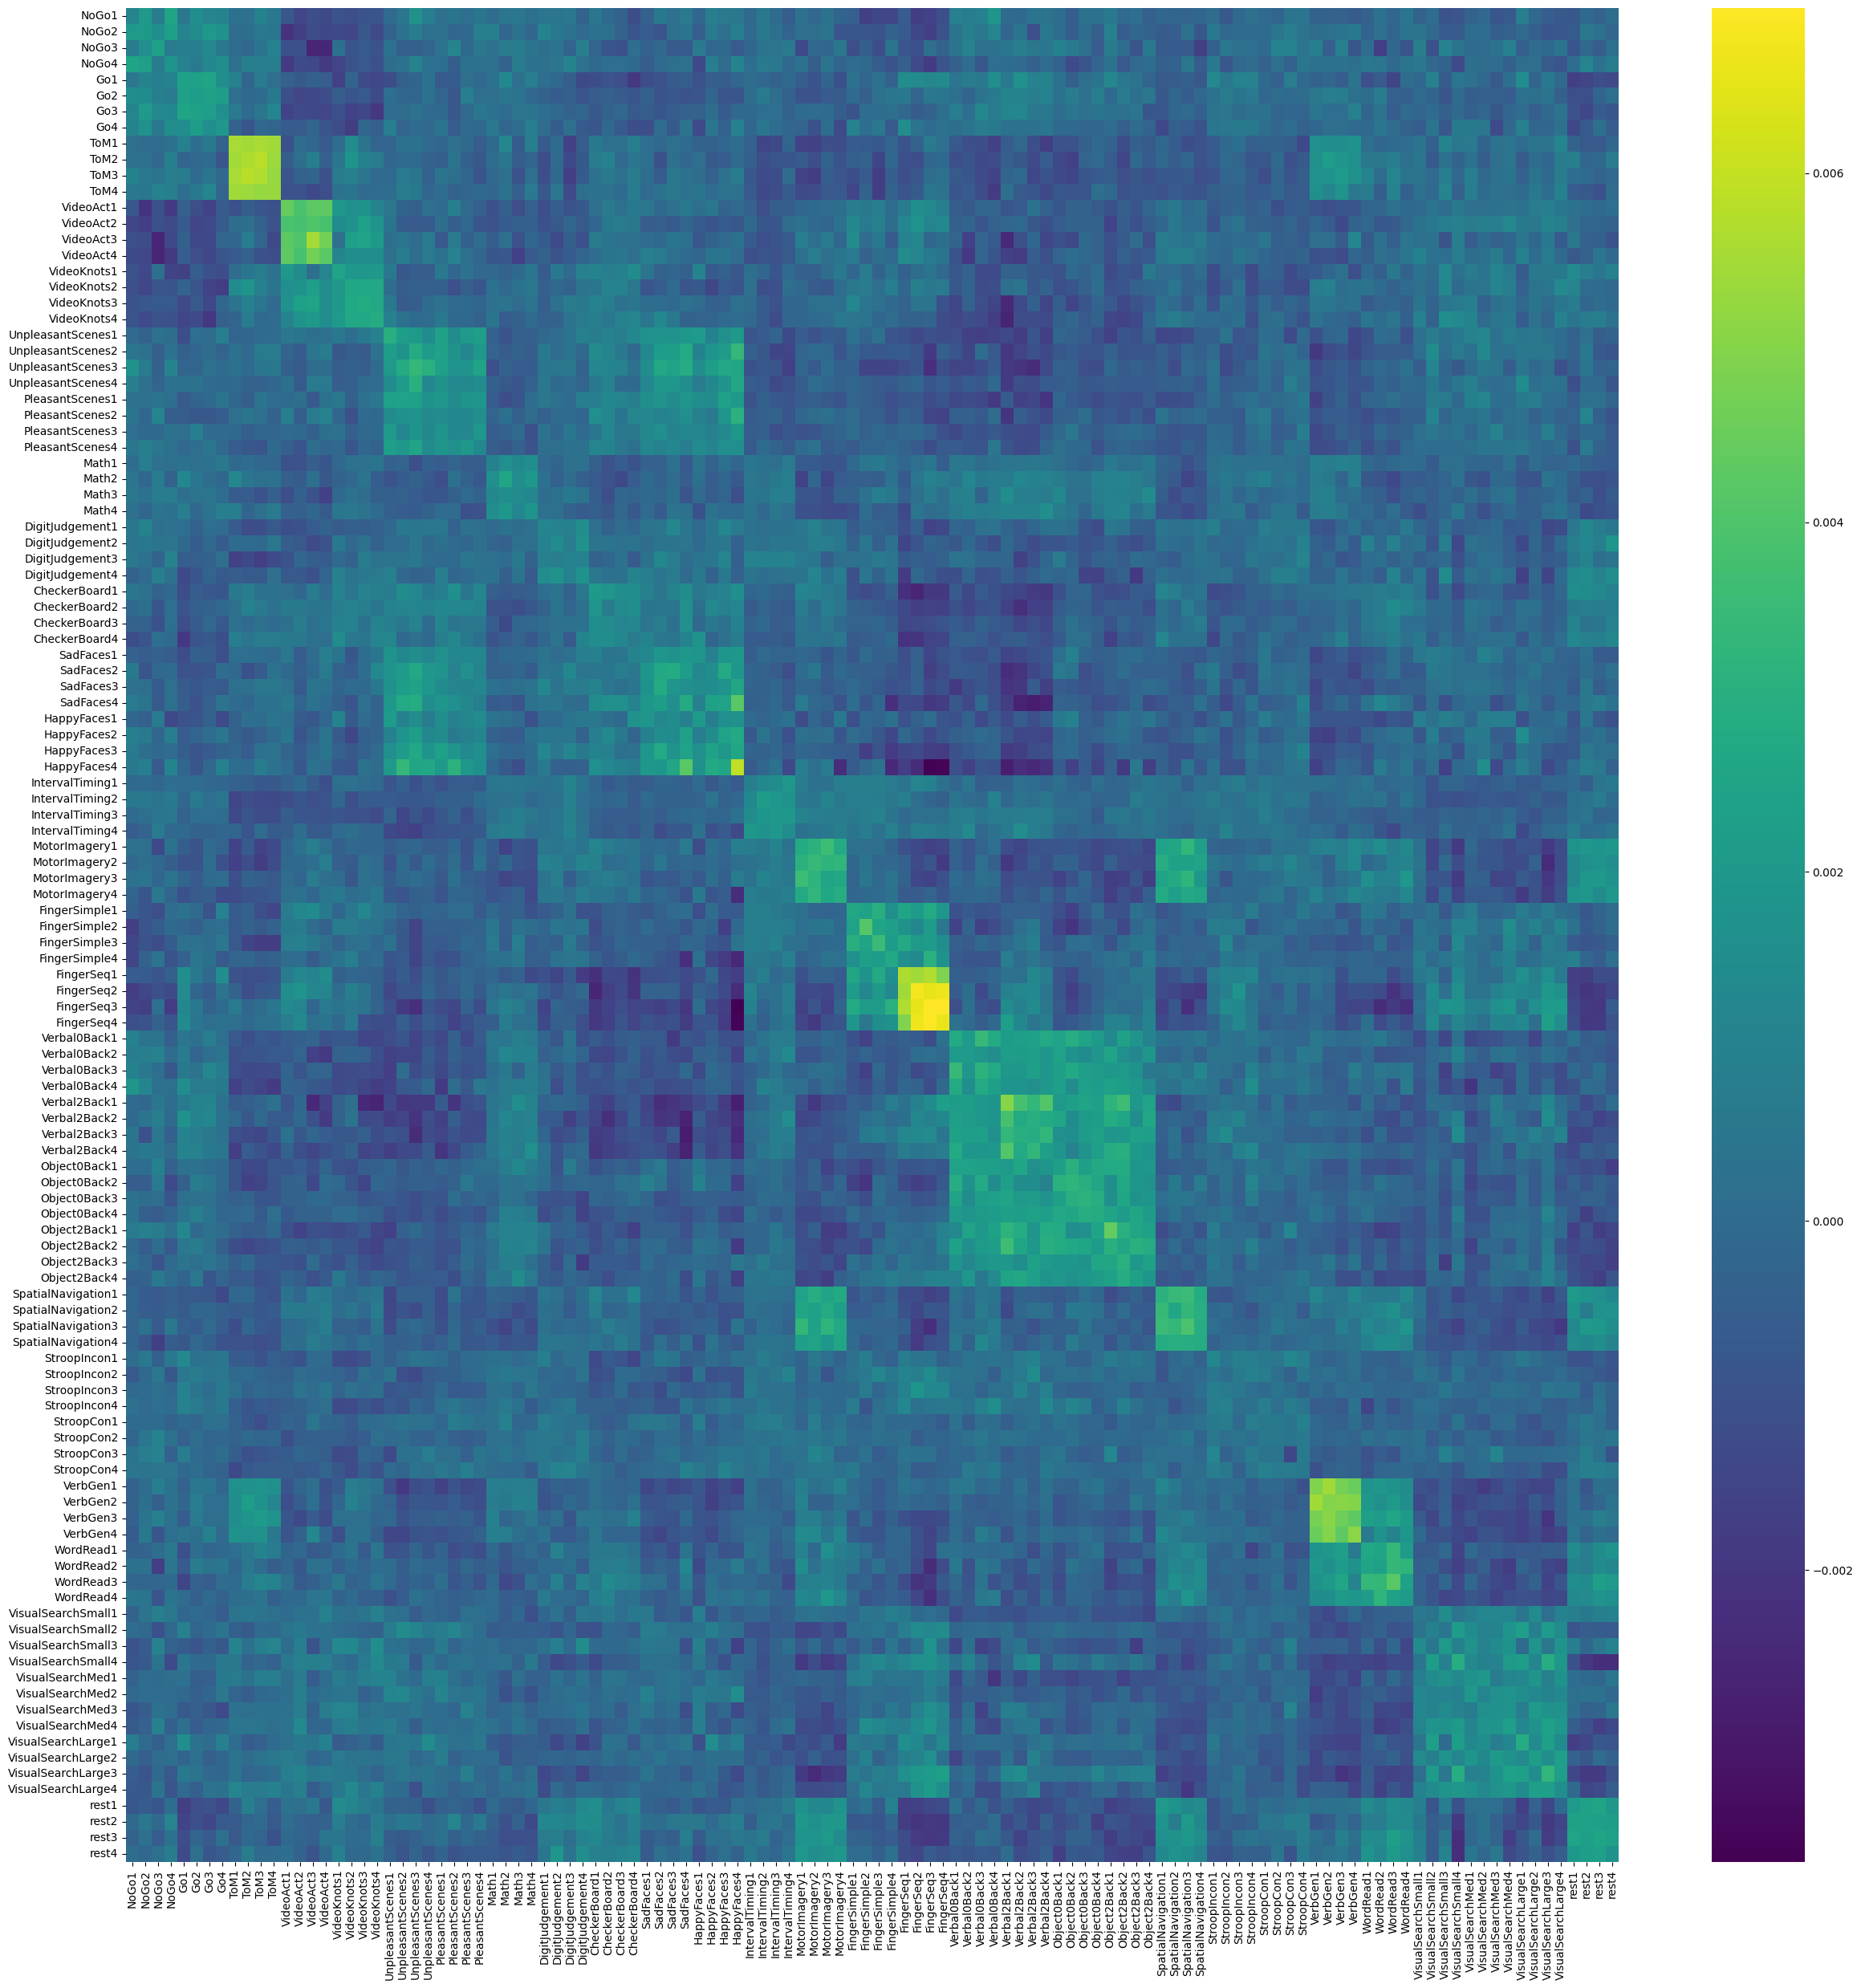

In [196]:
plt.figure(figsize=(30, 30))
sns.heatmap(G_individuals_averaged,xticklabels=cond_names, yticklabels=cond_names, cmap='viridis')

# Build combinations

In [197]:
D = build_combinations(G_individuals_averaged, strategy='random',n_iter=100,n_tasks=8)

In [198]:
np.unique(D.n_unique)

array([6, 7, 8], dtype=int64)

# Perform DCBC on combinations

In [199]:
#load model
with open('E:/data/model.pkl', 'rb') as f:
    model = pickle.load(f)

sym_type = 'unsym'
ar_model = model.arrange
ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())

P = new_data.shape[2]
K = ar_model.K

#load dist matrix
with open('E:/data/dist.pkl', 'rb') as f:
    dist = pickle.load(f)

dist = dist.to(DEVICE)


# load evaluation data_mdtb_s2
with open('E:/data/data_mdtb_s2_SUIT3.pkl', 'rb') as f:
    data_mdtb_s2 = pickle.load(f)



c:\Users\basse\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


In [200]:
def perform_dcbc_combination(data_train,cond_vec,part_vec,data_eval):
    
    x_matrix = ut.indicator(cond_vec)
    em_model = em.MixVMF(K=K, P=data_train.shape[2], X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([data_train])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation
    
    if isinstance(data_eval, np.ndarray):
        data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
    if isinstance(U_data, np.ndarray):
        U_data = pt.tensor(U_data, dtype=pt.get_default_dtype())
    
    Pindiv = pt.argmax(U_data, dim=1) + 1
    dcbc_indiv = calc_test_dcbc(Pindiv, data_eval, dist,progress_updates= False)
    return dcbc_indiv.mean()


In [201]:
# def perform_cos_combination(data_train,cond_vec,part_vec,data_eval):

#     x_matrix = ut.indicator(cond_vec)    
#     em_model = em.MixVMF(K=K, P=data_train.shape[2], X=x_matrix, part_vec=part_vec,
#                          subject_specific_kappa=False, parcel_specific_kappa=False, 
#                          subjects_equal_weight=True)
    
#     M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
#     M_1.initialize([data_train])

#     M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
#                                      fit_arrangement=False,
#                                      fit_emission= True,
#                                      first_evidence=False)
    

#     # Get the data-only parcellation
#     emloglik = M_1.emissions[0].Estep()
#     U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

#     parcellation = [U_data]
    
#     if isinstance(data_eval, np.ndarray):
#         data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
#     if isinstance(parcellation, np.ndarray):
#         parcellation = pt.tensor(parcellation, dtype=pt.get_default_dtype())

#     eval_num_runs = 16
#     eval_num_conds = 32

#     #create cond_vec and part_vec for evaluation data
#     cond_v_eval = np.tile(np.arange(1, eval_num_conds + 1), eval_num_runs)
#     part_v_eval = np.repeat(np.arange(1, eval_num_runs + 1), eval_num_conds)
#     #make into pt tensors
#     part_v_eval = pt.tensor(part_v_eval, dtype=pt.long)

#     x_matrix  = ut.indicator(cond_v_eval)

#     em_model = em.MixVMF(K=K, P=data_eval.shape[2], X=x_matrix, part_vec=part_v_eval,
#                             subject_specific_kappa=False, parcel_specific_kappa=False, 
#                             subjects_equal_weight=True)
    
#     M_eval = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
#     M_eval.initialize([data_eval])
    
#     cosserror_individuals = calc_test_error(M_eval, data_eval, parcellation)
#     return cosserror_individuals.mean()

In [202]:
counter = 0
def evaluate_combination_dcbc(combination):
    global counter
    counter += 1
    print(f"Combination {counter}")
    data_train, cond_v_train, part_v_train = combination_vectors(new_data, info_new, combination, n_repeats=2)
    dcbc_value = perform_dcbc_combination(data_train, cond_v_train, part_v_train, data_mdtb_s2)
    dcbc_value = dcbc_value.item()
    
    return dcbc_value

# def evaluate_combination_cos(combination):
#     global counter
#     counter += 1
#     print(f"Combination {counter}")
#     data_train, cond_v_train, part_v_train = combination_vectors(data_mdtb_s1, info, combination, n_repeats=3)
#     cos_value = perform_cos_combination(data_train, cond_v_train, part_v_train, data_mdtb_s2)
#     cos_value = cos_value.item()
    
#     return cos_value

In [203]:
unique_combinations_df = D[D['offset'] == D['offset'].min()].copy()
unique_combinations_df['dcbc'] = unique_combinations_df['combination'].apply(evaluate_combination_dcbc)


Combination 1
Likelihood decreased - terminating on iteration 1


KeyboardInterrupt: 

In [115]:
# unique_combinations_df = D[D['offset'] == D['offset'].min()].copy()
# unique_combinations_df['cos'] = unique_combinations_df['combination'].apply(evaluate_combination_cos)

In [138]:
D['combination'] = D['combination'].apply(tuple)
unique_combinations_df['combination'] = unique_combinations_df['combination'].apply(tuple)

# Now perform the merge operation using the tuple values
D = D.merge(
    unique_combinations_df[['combination', 'dcbc']], 
    on='combination', 
    how='left'
)

In [139]:
# # save D as tsv
# D.to_csv('dcbc_combinations_SUIT3_full_cerebellum.tsv', sep='\t', index=False)

In [140]:
# D = pd.read_csv('dcbc_combinations_SUIT3_full_cerebellum.tsv', sep='\t')

# Analyze the results

In [141]:
D

,offset,max_var,min_est,log_det,off_diag,composite_90var,composite_75var,composite_50var,composite_25var,composite_10var,composite_0.01var,condition_number,effective_rank,combination,has_repeats,n_unique,dcbc
0,0.000001,0.004623,3.004973e+06,-69.147922,0.000008,0.648769,0.540640,0.360424,0.180208,0.072078,0.007201,101987.345844,7.855291,"(7, 45, 68, 57, 112, 82, 96, 13)",0,8,0.044035
1,0.001000,0.011616,5.007627e+03,-45.437657,0.000008,0.648769,0.540640,0.360424,0.180208,0.072078,0.007201,101987.345844,7.855291,"(7, 45, 68, 57, 112, 82, 96, 13)",0,8,0.044035
2,0.100000,0.704616,6.954495e+01,-16.072263,0.000008,0.648769,0.540640,0.360424,0.180208,0.072078,0.007201,101987.345844,7.855291,"(7, 45, 68, 57, 112, 82, 96, 13)",0,8,0.044035
3,0.000001,0.004383,3.005759e+06,-69.569822,0.000013,0.648120,0.540098,0.360061,0.180024,0.072002,0.007189,102105.411847,7.831192,"(10, 23, 81, 7, 24, 74, 92, 20)",0,8,0.040937
4,0.001000,0.011376,5.104625e+03,-45.594229,0.000013,0.648120,0.540098,0.360061,0.180024,0.072002,0.007189,102105.411847,7.831192,"(10, 23, 81, 7, 24, 74, 92, 20)",0,8,0.040937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.001000,0.009571,5.684119e+03,-46.575889,0.000006,0.643247,0.536038,0.357357,0.178675,0.071466,0.007141,101563.001453,7.664924,"(95, 41, 71, 69, 70, 23, 86, 106)",0,8,0.049899
296,0.100000,0.702571,6.974577e+01,-16.092531,0.000006,0.643247,0.536038,0.357357,0.178675,0.071466,0.007141,101563.001453,7.664924,"(95, 41, 71, 69, 70, 23, 86, 106)",0,8,0.049899
297,0.000001,0.004110,4.002887e+06,-75.455832,0.000012,0.647383,0.539484,0.359652,0.179820,0.071921,0.007181,102285.505181,7.794082,"(39, 31, 37, 38, 56, 87, 28, 36)",0,8,0.047323
298,0.001000,0.011103,5.377205e+03,-45.895466,0.000012,0.647383,0.539484,0.359652,0.179820,0.071921,0.007181,102285.505181,7.794082,"(39, 31, 37, 38, 56, 87, 28, 36)",0,8,0.047323


In [142]:
# subset only the 0.001 offset
A = D[D['offset'] == 0.001].copy()

In [143]:
# show many combinations are repeated
n_repeated = len(A[A['has_repeats'] == True])
n_unique = len(A[A['has_repeats'] == False])

n_repeated, n_unique


(21, 79)

<Axes: xlabel='dcbc', ylabel='Count'>

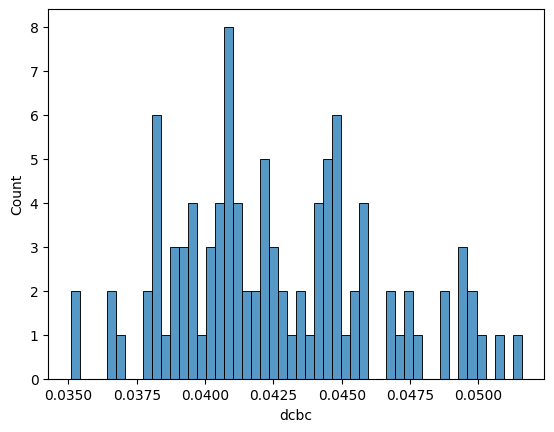

In [144]:
# plot the distribution of the DCBC values
sns.histplot(A['dcbc'], bins=50)

<Axes: xlabel='min_est', ylabel='max_var'>

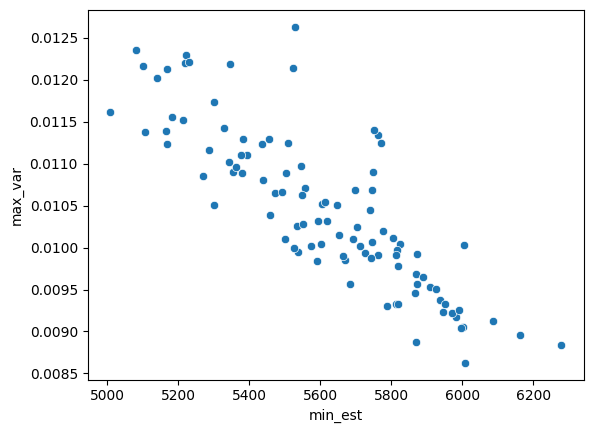

In [145]:
sns.scatterplot(x='min_est', y='max_var', data=A)

In [146]:
# get the two variables for Dcbc and log_det
log_det_list = A['log_det'].values
dcbc_list = A['dcbc'].values

from scipy.stats import pearsonr
r_value, p_value = pearsonr(log_det_list, dcbc_list)

print(f"Correlation between log_det and DCBC: {r_value}, p-value: {p_value}")

Correlation between log_det and DCBC: -0.11638975083273657, p-value: 0.24883298481841326


In [147]:
# get the two variables for DCBC and min_est
min_est_list = A['min_est'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(min_est_list, dcbc_list)

print(f"Correlation between min_est and DCBC: {r_value}, p-value: {p_value}")


Correlation between min_est and DCBC: 0.05933844857873051, p-value: 0.5575790107583197


In [148]:
# get the two variables for DCBC and max_var
max_var_list = A['max_var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18116526874599587, p-value: 0.07125744702860767


In [149]:
# get the two variables for DCBC and max_var
max_var_list = A['effective_rank'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.15601774509273808, p-value: 0.12112455550731889


In [150]:
# get the two variables for DCBC and max_var
max_var_list = A['max_var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18116526874599587, p-value: 0.07125744702860767


In [151]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_90var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18115232479108362, p-value: 0.07127800096886698


In [152]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_75var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18112642572447274, p-value: 0.0713191409294213


In [153]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_50var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18104863919245084, p-value: 0.07144281792656867


In [154]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_10var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18010466761685132, p-value: 0.07295752538948634
